## Анализ зависимости суммы операции и типа операции

In [1]:
import pyspark
from pyspark.ml import Transformer, Pipeline
from pyspark.ml.util import DefaultParamsReadable, DefaultParamsWritable
from pyspark.sql.functions import first, sum, col, max, min,avg
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# создание spark-сессии
spark =SparkSession.builder \
    .appName("analysis") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "2g") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.memory.offHeap.enabled", "true") \
    .config("spark.memory.offHeap.size", "1g") \
    .getOrCreate()

## ANALYTICS POSTPROCESS

In [3]:
train_path = "../datasets/joined/train_data.parquet"
df_train = spark.read.parquet(train_path)

c:\antifraud_hak\antifraud_hak\.venv\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


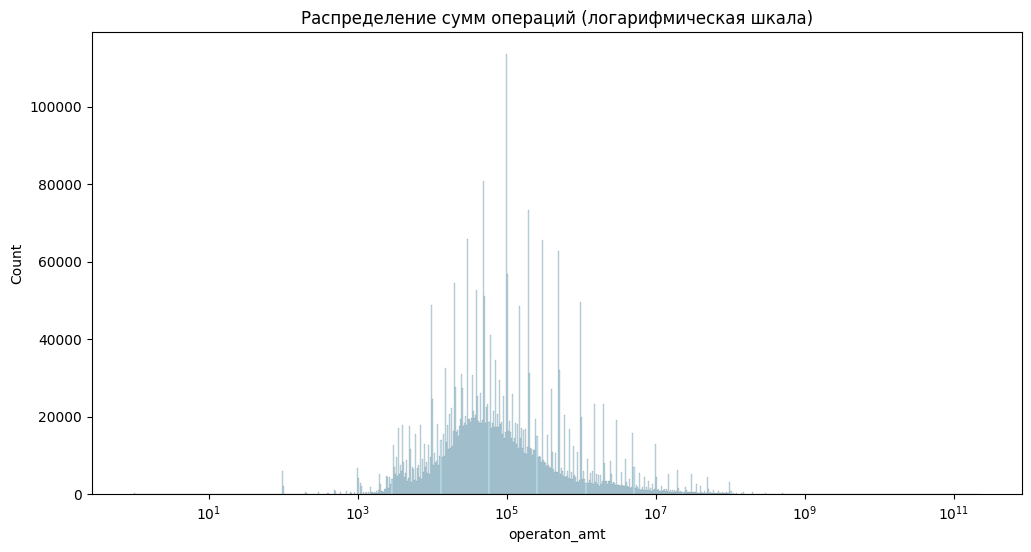

In [ ]:
# 1. Берем 10% данных без повторений
# Это безопасно для памяти, если общий объем данных велик
pdf = df_train.select("operaton_amt").sample(False, 0.1).toPandas()

# 2. Строим гистограмму
plt.figure(figsize=(12, 6))
# Параметр log_scale=True решит проблему визуализации
sns.histplot(data=pdf, x="operaton_amt", kde=True, log_scale=True, color="skyblue")
plt.title("Распределение сумм операций (логарифмическая шкала)")
plt.show()

## ИЩЕМ ФРОД

c:\antifraud_hak\antifraud_hak\.venv\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


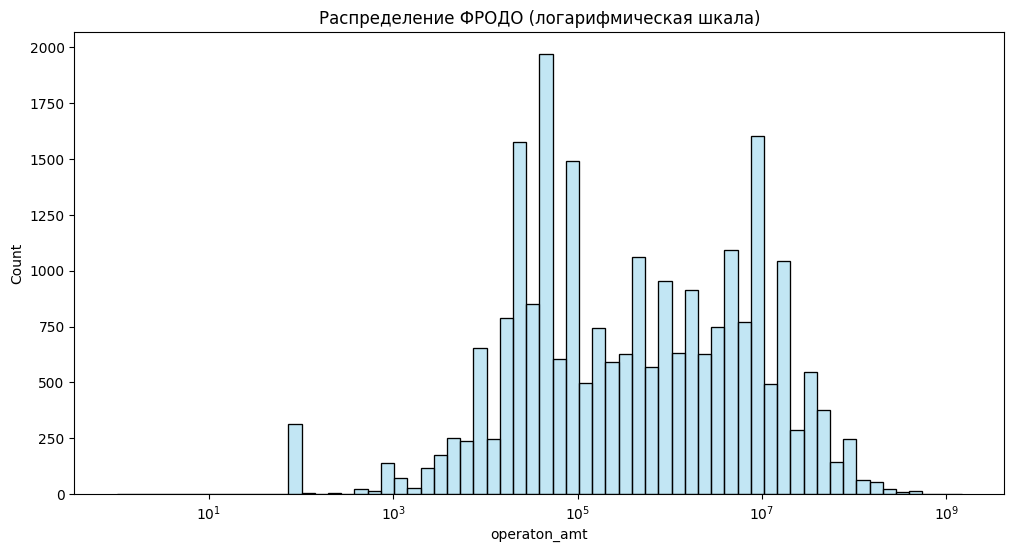

In [ ]:
# 1. Берем 10% данных без повторений
# Это безопасно для памяти, если общий объем данных велик
pdf = df_train.select("operaton_amt").filter('target == 1').toPandas()

# 2. Строим гистограмму
plt.figure(figsize=(12, 6))
# Параметр log_scale=True решит проблему визуализации
sns.histplot(data=pdf, x="operaton_amt", kde=True, log_scale=True, color="skyblue")
plt.title("Распределение ФРОДО (логарифмическая шкала)")
plt.show()

## РАСПРЕДЕЛЕНИЕ ФРОДОВ ПЕРЕВОДОВ В ЗАВИСИМОСТИ ОТ ТИПА ОПЕРАЦИИ

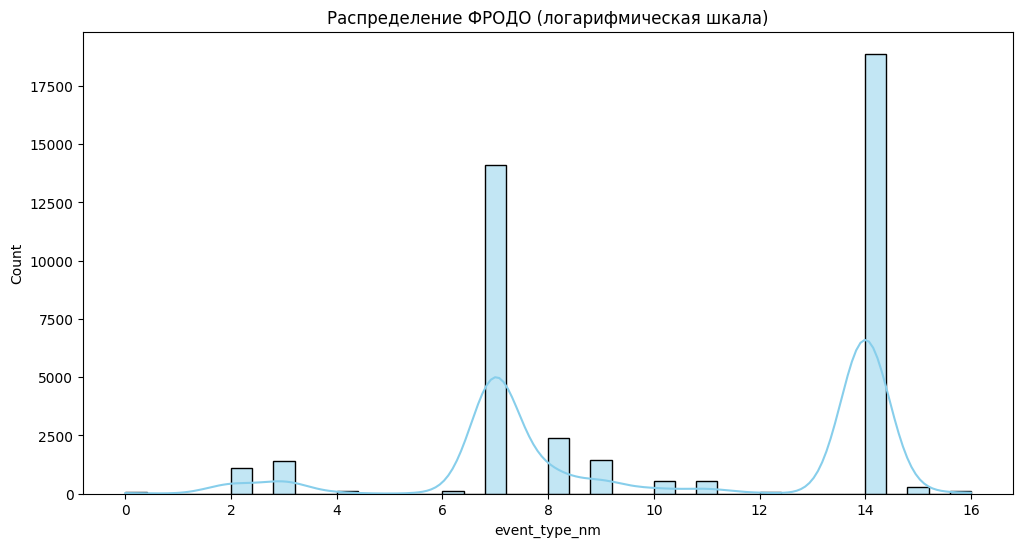

In [ ]:
# Это безопасно для памяти, если общий объем данных велик
pdf = df_train.select('event_type_nm').filter('target == 1').toPandas()

# 2. Строим гистограмму
plt.figure(figsize=(12, 6))
# Параметр log_scale=True решит проблему визуализации
sns.histplot(data=pdf, x="event_type_nm", kde=True, color="skyblue")
plt.title("Распределение ФРОДО (логарифмическая шкала)")
plt.show()

## ВСЕГДА ЛИ ФРОД В ВЗЛОМАННЫХ УСТРОЙСТВАХ?

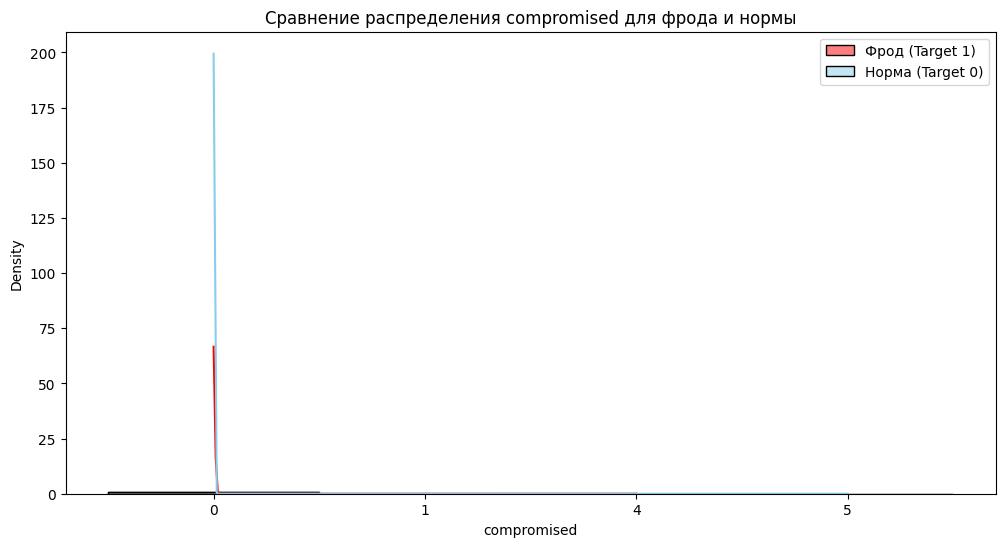

In [ ]:
# Подготовка данных
pdf1 = df_train.filter('target == 1').select('compromised').toPandas()
# Для target=0 берем выборку, чтобы не перегрузить память
pdf2 = df_train.filter('target == 0').select('compromised').sample(False, 0.1).toPandas()

plt.figure(figsize=(12, 6))

# Рисуем оба распределения на одних осях
# stat="density" нормализует площади графиков, чтобы их можно было сравнить при разном кол-ве строк
sns.histplot(data=pdf1, x="compromised", kde=True, color="red", label="Фрод (Target 1)", stat="density", common_norm=False)
sns.histplot(data=pdf2, x="compromised", kde=True, color="skyblue", label="Норма (Target 0)", stat="density", common_norm=False)

plt.legend()
plt.title("Сравнение распределения compromised для фрода и нормы")
# Добавьте это, если данные сильно разбросаны:
# plt.xscale('log') 

plt.show()


## РАСПРЕДЕЛЕНИЕ СТОИМОСТИ ОПЕРАЦИЙ В ЗАВИСИМОСТИ ОТ ТИПА ОПИСАНИЯ ОПЕРАЦИИ

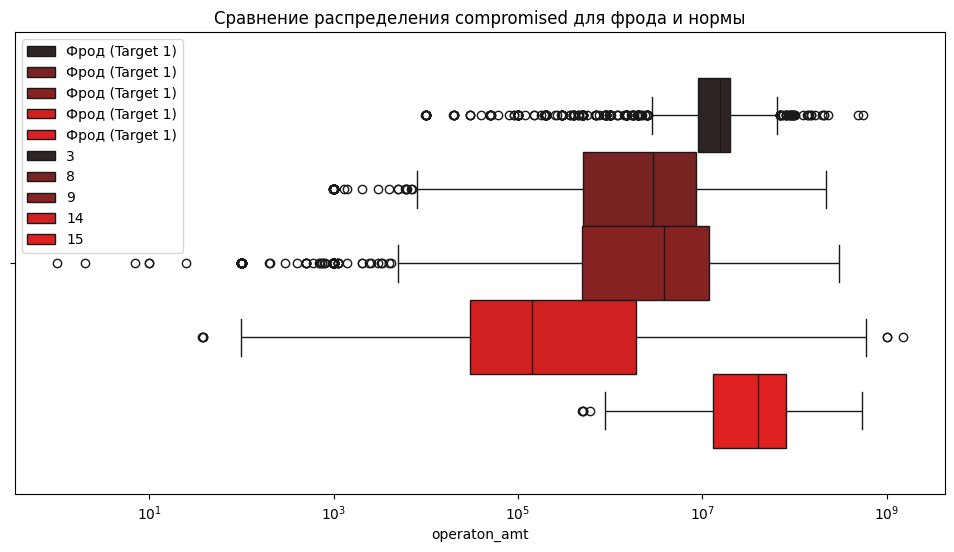

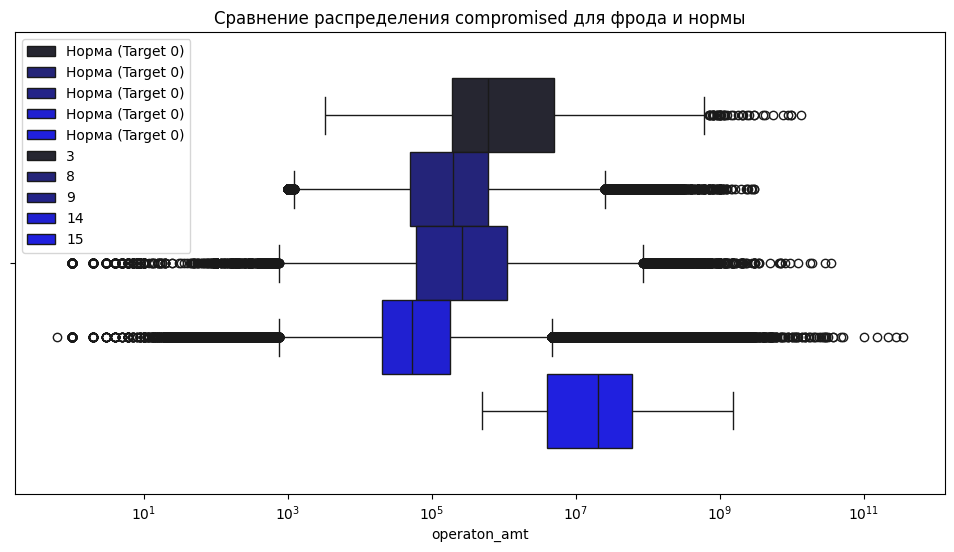

In [ ]:
# Подготовка данных
pdf1 = df_train.filter('target == 1 AND operaton_amt>0').select('event_type_nm','operaton_amt').toPandas()
# Для target=0 берем выборку, чтобы не перегрузить память
pdf2 = df_train.filter('target == 0 AND operaton_amt>0' ).select('event_type_nm','operaton_amt').sample(False, 0.1).toPandas()

plt.figure(figsize=(12, 6))

# Рисуем оба распределения на одних осях
# stat="density" нормализует площади графиков, чтобы их можно было сравнить при разном кол-ве строк
sns.boxplot(data=pdf1, x="operaton_amt", palette='dark:red', label="Фрод (Target 1)", log_scale=True, hue='event_type_nm')
plt.legend()
plt.title("Сравнение распределения compromised для фрода и нормы")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=pdf2, x="operaton_amt", palette='dark:blue', label="Норма (Target 0)",log_scale=True, hue='event_type_nm')
plt.legend()
plt.title("Сравнение распределения compromised для фрода и нормы")
plt.show()


In [ ]:
value = df_train.filter('target == 1').select('customer_id').distinct().count()
print(f"Кол-во клиентов подвершся фроду: {value}")

Кол-во клиентов подвершся фроду: 18210


In [ ]:

fraud_rating = (
    df_train
    .filter('target == 1') # Оставляем только фрод
    .groupBy('customer_id') # Группируем по пользователям
    .agg(F.count('target').alias('fraud_count')) # Считаем количество
    .orderBy(F.col('fraud_count').desc()) # Сортируем: самые активные сверху
)

fraud_rating.show(10)

+---------------+-----------+
|    customer_id|fraud_count|
+---------------+-----------+
|123861857500231|        111|
|123784548087344|         50|
|123363641295439|         40|
|123174662731955|         39|
|123380821162557|         38|
|123123123123574|         38|
|123758778284194|         36|
|123604159462120|         31|
|123853267564419|         31|
|123698648742241|         28|
+---------------+-----------+
only showing top 10 rows


In [4]:
df_train.select('pos_cd').distinct().count()

23